In [101]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   str    
 1   industry                  1328 non-null   str    
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   str    
 5   location                  1399 non-null   str    
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 102.9 KB


### Data Prep

- Check if the missing values are presented in the features.
- If there are missing values:
- For categorical features, replace them with 'NA'
- For numerical features, replace with with 0.0

In [95]:
# df.isna().sum()

In [96]:
# df.dtypes

In [105]:
categorical = [
    'lead_source', 'industry', 'employment_status', 'location'
]

numerical = [
    'number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score'
]    

In [98]:
# df[numerical].describe().round(1)

In [104]:
# df[categorical] = df[categorical].fillna('NA')
# df[numerical] = df[numerical].fillna(0)
# df.isna().sum()

### Q1

What is the mode for the column industry?

In [106]:
df[categorical].describe()

,lead_source,industry,employment_status,location
count,1334,1328,1362,1399
unique,5,7,4,7
top,organic_search,retail,self_employed,north_america
freq,282,203,352,225


In [108]:
df['industry'].value_counts()

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
Name: count, dtype: int64

*the answer is retail*

### Q2

Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

In [107]:
df[numerical].describe()

,number_of_courses_viewed,annual_income,interaction_count,lead_score
count,1462.000000,1281.000000,1462.000000,1462.000000
mean,2.031464,59886.273224,2.976744,0.506108
std,1.449717,15070.140389,1.681564,0.288465
min,0.000000,13929.000000,0.000000,0.000000
25%,1.000000,49698.000000,2.000000,0.262500
50%,2.000000,60148.000000,3.000000,0.510000
75%,3.000000,69639.000000,4.000000,0.750000
max,9.000000,109899.000000,11.000000,1.000000


In [109]:
df.corr(numeric_only=True)

,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
number_of_courses_viewed,1.000000,0.031551,-0.023565,-0.004879,0.435914
annual_income,0.031551,1.000000,0.048618,0.005334,0.078256
interaction_count,-0.023565,0.048618,1.000000,0.009888,0.374573
lead_score,-0.004879,0.005334,0.009888,1.000000,0.193673
converted,0.435914,0.078256,0.374573,0.193673,1.000000


In [110]:
df[numerical].corrwith(df.converted).sort_values(ascending=False)

number_of_courses_viewed    0.435914
interaction_count           0.374573
lead_score                  0.193673
annual_income               0.078256
dtype: float64

*interaction_count and lead_score
number_of_courses_viewed and lead_score*

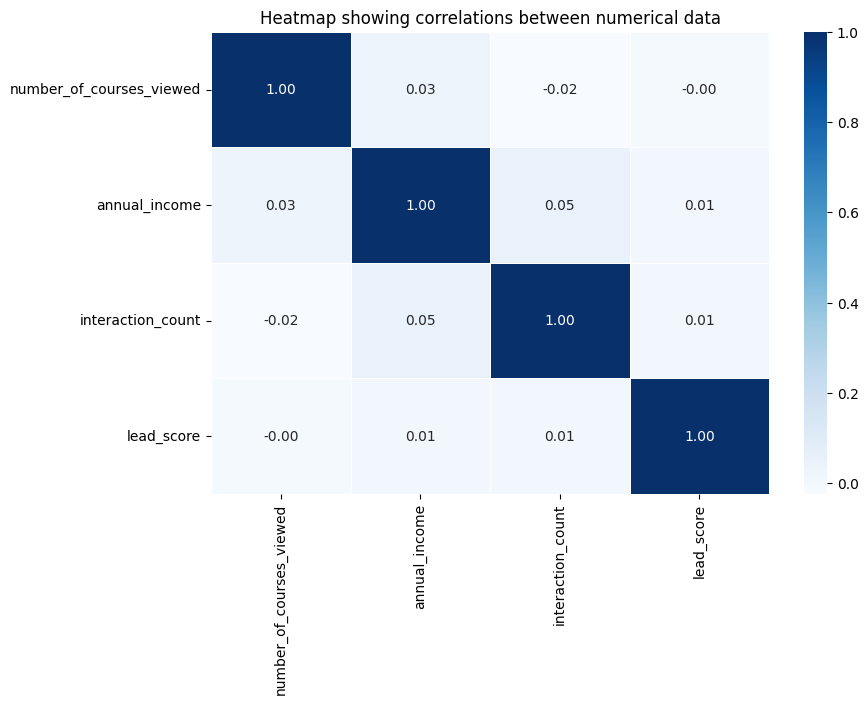

In [111]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[numerical].corr(), 
            annot = True,
            cmap = "Blues",
            fmt=".2f",
            linewidths=.5
           )
plt.title('Heatmap showing correlations between numerical data')
plt.show()

In [112]:
df[numerical].corr().unstack().sort_values(ascending=False)

number_of_courses_viewed  number_of_courses_viewed    1.000000
annual_income             annual_income               1.000000
lead_score                lead_score                  1.000000
interaction_count         interaction_count           1.000000
annual_income             interaction_count           0.048618
interaction_count         annual_income               0.048618
annual_income             number_of_courses_viewed    0.031551
number_of_courses_viewed  annual_income               0.031551
lead_score                interaction_count           0.009888
interaction_count         lead_score                  0.009888
annual_income             lead_score                  0.005334
lead_score                annual_income               0.005334
                          number_of_courses_viewed   -0.004879
number_of_courses_viewed  lead_score                 -0.004879
                          interaction_count          -0.023565
interaction_count         number_of_courses_viewed   -0

### Split the data

- Split your data in train/val/test sets with 60%/20%/20% distribution.
- Use Scikit-Learn for that (the train_test_split function) and set the seed to 42.
- Make sure that the target value converted is not in your dataframe.

In [113]:
SEED = 42

In [115]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=SEED)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=SEED)

assert len(df) == (len(df_train) + len(df_val) + len(df_test))

In [116]:
len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [117]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [118]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

### Q3

- Calculate the mutual information score between converted and other categorical variables in the dataset. Use the training set only.
- Round the scores to 2 decimals using round(score, 2).
- Which of these variables has the biggest mutual information score?
    - industry
    - location
    - lead_source
    - employment_status

In [121]:
def calculate_mi(series):
    return mutual_info_score(series, df_train.converted)

In [122]:
cat = ['lead_source', 'industry', 'employment_status', 'location']
numeric = ['number_of_courses_viewed', 'annual_income', 'interaction_count',
       'lead_score']

In [123]:
df_mi = df_train[cat].fillna('NA').apply(calculate_mi)
df_mi = df_mi.sort_values(ascending=False).to_frame(name='MI')
df_mi

AttributeError: 'DataFrame' object has no attribute 'converted'

In [50]:
mi = df_full_train[categorical].apply(mutual_info_converted_score)
mi.sort_values(ascending=False)

lead_source          0.025665
employment_status    0.013258
industry             0.011685
location             0.002253
dtype: float64

### Q4
- Now let's train a logistic regression.
- Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
- Fit the model on the training dataset.
    - To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
    - model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
- Calculate the accuracy on the validation dataset and round it to 2 decimal digits.
- What accuracy did you get?

In [61]:
from sklearn.feature_extraction import DictVectorizer

In [59]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [60]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

# in val data, we only do the transform, not fit and transform

In [78]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import mutual_info_score, accuracy_score

In [64]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The 

In [66]:
model.predict(X_train)
model.predict_proba(X_val)

array([[0.38807837, 0.61192163],
       [0.20017383, 0.79982617],
       [0.46978656, 0.53021344],
       [0.52868521, 0.47131479],
       [0.42933869, 0.57066131],
       [0.55772832, 0.44227168],
       [0.12872331, 0.87127669],
       [0.15116885, 0.84883115],
       [0.16709963, 0.83290037],
       [0.38502199, 0.61497801],
       [0.45031974, 0.54968026],
       [0.21846912, 0.78153088],
       [0.30960215, 0.69039785],
       [0.22982878, 0.77017122],
       [0.4734056 , 0.5265944 ],
       [0.08293575, 0.91706425],
       [0.46829366, 0.53170634],
       [0.57876952, 0.42123048],
       [0.69853545, 0.30146455],
       [0.15118417, 0.84881583],
       [0.20511347, 0.79488653],
       [0.26329626, 0.73670374],
       [0.55472789, 0.44527211],
       [0.35161617, 0.64838383],
       [0.5823118 , 0.4176882 ],
       [0.24606582, 0.75393418],
       [0.09833884, 0.90166116],
       [0.66096952, 0.33903048],
       [0.56818569, 0.43181431],
       [0.0319319 , 0.9680681 ],
       [0.

In [85]:
y_pred = model.predict(X_val)

In [86]:
original_score = accuracy_score(y_val, y_pred)
original_score

0.6996587030716723

In [87]:
accuracy = np.round(original_score, 2)
print(f'Accuracy = {accuracy}')

Accuracy = 0.7


### Q5

- Let's find the least useful feature using the feature elimination technique.
- Train a model using the same features and parameters as in Q4 (without rounding).
- Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
- For each feature, calculate the difference between the original accuracy and the accuracy without the feature.